In [1]:
from torch.utils.data import DataLoader
from miao import VolumeDataset, load_config

In [2]:
config = load_config("/groups/troidl/home/troidlj/miaio/examples/config.yaml")
dataset = VolumeDataset(config)

VolumeDataset: 2 volume(s), 1000 samples/epoch, patch_size=[128, 128, 32]
  [Jiefu Cerebellum FIB-SEM]
    image: axes='zyx', shape=[13745, 7627, 6274], dtype=uint8
    scale 0: voxel_size=[16.0, 16.0, 16.0] nanometer
    scale 1: voxel_size=[32.0, 32.0, 32.0] nanometer
    scale 2: voxel_size=[64.0, 64.0, 64.0] nanometer
    label: axes='zyx', shape=[13745, 7627, 6274], dtype=uint32
    sampling: weight=0.50, center_range=[[1197, 1457, 1132], [5561, 4773, 6020]]
    normalize: uint8 -> [0, 1]
  [H01 Human Cortex]
    image: axes='xyz', shape=[16384, 16384, 1024], dtype=uint8
    scale 0: voxel_size=[4.0, 4.0, 33.0] nanometer
    scale 1: voxel_size=[8.0, 8.0, 33.0] nanometer
    scale 2: voxel_size=[16.0, 16.0, 33.0] nanometer
    label: axes='xyz', shape=[8192, 8192, 1024], dtype=uint64
    sampling: weight=0.50, center_range=[[512, 512, 16], [15872, 15872, 1008]]
    normalize: uint8 -> [0, 1]
  output: axes='xyz', tensor_shape=(1, L, X, Y, Z)


In [3]:
x = dataset[0]

print(x['meta'])
print(x['img'].shape)
print(x['bbox'].shape)

{'volume': 'Jiefu Cerebellum FIB-SEM', 'coordinate': [2972, 4542, 4494], 'scale_levels': [0, 1, 2]}
torch.Size([1, 3, 128, 128, 32])
torch.Size([3, 2, 3])


In [4]:
loader = DataLoader(dataset, batch_size=4, shuffle=True)

batch = next(iter(loader))

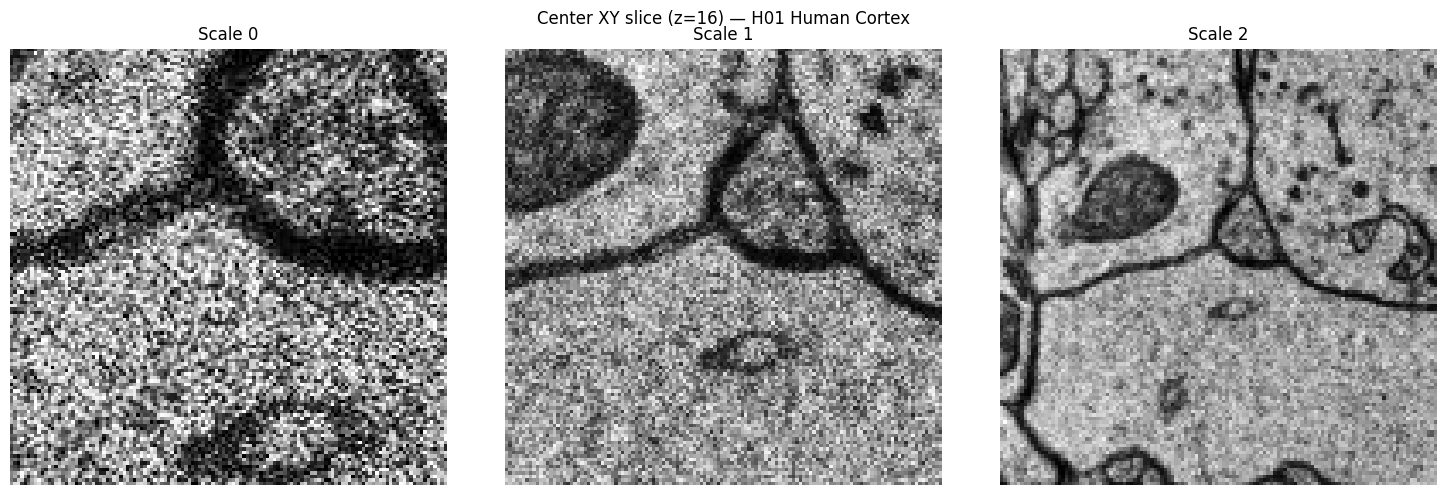

In [5]:
import matplotlib.pyplot as plt

sample = dataset[0]
img = sample["img"]  # (1, L, X, Y, Z)
num_levels = img.shape[1]
center_z = img.shape[4] // 2

fig, axes = plt.subplots(1, num_levels, figsize=(5 * num_levels, 5))
if num_levels == 1:
    axes = [axes]
for i in range(num_levels):
    axes[i].imshow(img[0, i, :, :, center_z].numpy().T, cmap="gray", origin="lower")
    axes[i].set_title(f"Scale {sample['meta']['scale_levels'][i]}")
    axes[i].axis("off")
plt.suptitle(f"Center XY slice (z={center_z}) — {sample['meta']['volume']}")
plt.tight_layout()
plt.show()